Zero Dispersion Wavelength: 1.2729 μm = 1272.9 nm
 wavelength-a fiber better works!)


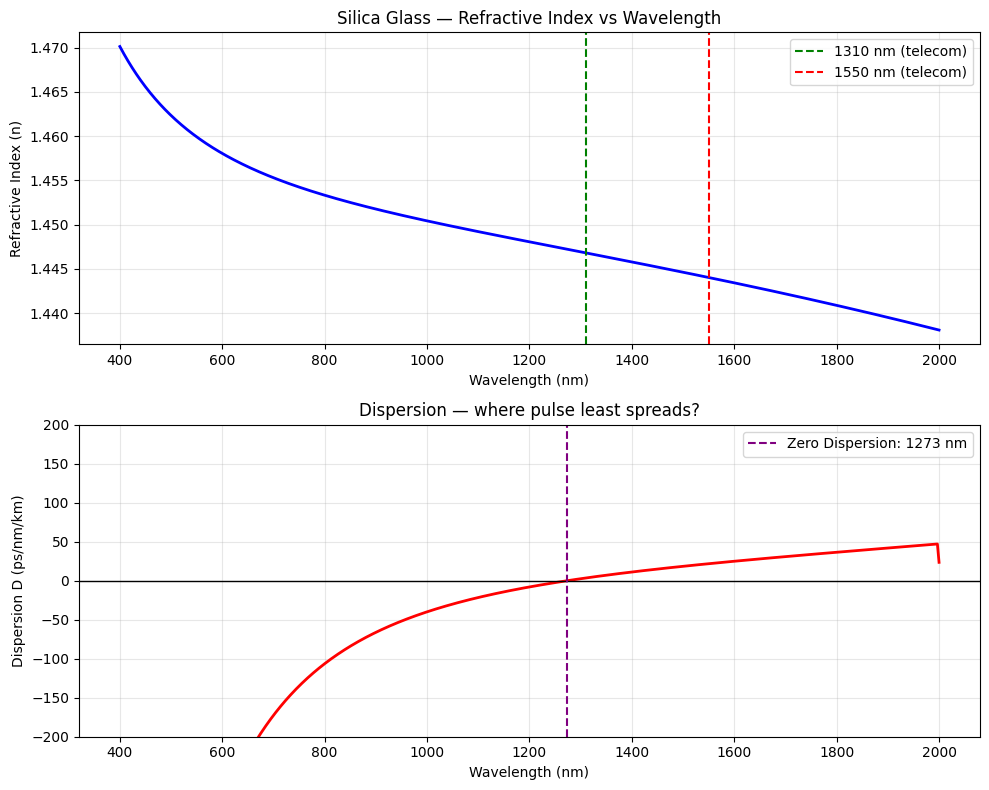

Graph saved!


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Silica glass-এর Sellmeier coefficients
# (এগুলো experimentally measured — বিজ্ঞানীরা কাচ বানিয়ে measure করেছেন)
B1, B2, B3 = 0.6961663, 0.4079426, 0.8974794
C1, C2, C3 = 0.0684043**2, 0.1162414**2, 9.896161**2

def sellmeier(wavelength_um):
    """
    wavelength_um: আলোর রং, micrometers-এ
    return: refractive index n
    """
    lam2 = wavelength_um**2
    n_squared = (1
                 + B1*lam2/(lam2 - C1)
                 + B2*lam2/(lam2 - C2)
                 + B3*lam2/(lam2 - C3))
    return np.sqrt(n_squared)

# Wavelength range: 0.4μm (বেগুনি) থেকে 2.0μm (infrared)
wavelengths = np.linspace(0.4, 2.0, 1000)
n = sellmeier(wavelengths)

# Dispersion parameter D বের করা
# D বলে: প্রতি nm wavelength difference-এ pulse কতটা ছড়ায়
# D = -λ/c * d²n/dλ²
c = 3e8  # আলোর বেগ m/s

# Numerical derivative (calculus!)
dn_dlam   = np.gradient(n, wavelengths)
d2n_dlam2 = np.gradient(dn_dlam, wavelengths)

# wavelength কে meter-এ convert করে D বের করা (ps/nm/km)
lam_m = wavelengths * 1e-6
D = -(lam_m / c) * d2n_dlam2 * 1e6 * 1e12  

# Zero Dispersion Wavelength খোঁজা
# এখানে D=0, মানে pulse সবচেয়ে কম ছড়ায়!
zero_idx = np.argmin(np.abs(D))
zdw = wavelengths[zero_idx]

print(f"Zero Dispersion Wavelength: {zdw:.4f} μm = {zdw*1000:.1f} nm")
print(f" wavelength-a fiber better works!)")

# Plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

# Plot 1: Refractive Index
ax1.plot(wavelengths*1000, n, 'b-', linewidth=2)
ax1.set_xlabel('Wavelength (nm)')
ax1.set_ylabel('Refractive Index (n)')
ax1.set_title('Silica Glass — Refractive Index vs Wavelength')
ax1.grid(True, alpha=0.3)
ax1.axvline(1310, color='green', linestyle='--', label='1310 nm (telecom)')
ax1.axvline(1550, color='red', linestyle='--', label='1550 nm (telecom)')
ax1.legend()

# Plot 2: Dispersion
ax2.plot(wavelengths*1000, D, 'r-', linewidth=2)
ax2.axhline(0, color='black', linewidth=1)
ax2.axvline(zdw*1000, color='purple', linestyle='--',
            label=f'Zero Dispersion: {zdw*1000:.0f} nm')
ax2.set_xlabel('Wavelength (nm)')
ax2.set_ylabel('Dispersion D (ps/nm/km)')
ax2.set_title('Dispersion — where pulse least spreads?')
ax2.grid(True, alpha=0.3)
ax2.legend()
ax2.set_ylim(-200, 200)

plt.tight_layout()
plt.savefig('fiber_dispersion.png', dpi=150, bbox_inches='tight')
plt.show()
print("Graph saved!")